<a href="https://colab.research.google.com/github/Vestal1/nlp-analyse-klarschiff-hro/blob/main/notebooks/klarschiff_nlp_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Untersuchung der Klarschiff.HRO-Meldungen

#In diesem Projekt wird der Datensatz Klarschiff.HRO mit einfachen Verfahren aus dem Bereich Natural Language Processing untersucht. Zuerst wird der Datensatz betrachtet und bereinigt. Danach werden CountVectorizer und TF-IDF sowie die Verfahren LDA und NMF ausprobiert.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bibliotheken wurden geladen.")



Bibliotheken wurden geladen.


## 1. Datensatz einlesen

#Zuerst wird der Datensatz direkt von der Open-Data-Seite der Stadt Rostock eingelesen. Danach werden die ersten Zeilen und die Größe des Datensatzes betrachtet.

In [3]:
url = "https://geo.sv.rostock.de/download/opendata/klarschiffhro-meldungen/klarschiffhro-meldungen.csv"

df = pd.read_csv(url)

print("Anzahl Zeilen und Spalten:", df.shape)
df.head()

Anzahl Zeilen und Spalten: (2619, 13)


,latitude,longitude,nummer,typ,hauptkategorie,unterkategorie,status,statusinformation,unterstuetzungen,beschreibung,erstellungsdatum,letztes_aenderungsdatum,aktuelle_zustaendigkeit
0,54.125287,12.141777,124715,Problem,Müll/Schmutz,Sperrmüll,in Bearbeitung,Die Meldung wurde an die Stadtentsorgung Rosto...,NaN,Möbelteile,2026/09/04,2026/09/08,Amt für Umwelt- und Klimaschutz [delegiert an:...
1,54.139035,12.047776,124377,Problem,Müll/Schmutz,Altfahrzeug/Schrottfahrrad,in Bearbeitung,Vielen Dank für Ihren Hinweis. Der Prozess zur...,NaN,Erstaufnahme abgestelltes Fahrzeug Ausländisch...,2026/08/28,2026/09/07,Amt für Umwelt- und Klimaschutz
2,54.122286,12.053965,123263,Problem,Müll/Schmutz,Sperrmüll,offen,NaN,NaN,NaN,2026/08/03,2026/08/03,Amt für Umwelt- und Klimaschutz
3,54.083808,12.115074,124576,Problem,Müll/Schmutz,Elektroschrott,gelöst,Die Meldung wurde an die Stadtentsorgung Rosto...,NaN,Gegenüber der Hundertmännerstr. 4 befindet sic...,2026/09/01,2026/09/08,Amt für Umwelt- und Klimaschutz [delegiert an:...
4,54.080055,12.185793,122967,Problem,Müll/Schmutz,Sperrmüll,offen,NaN,NaN,NaN,2026/07/25,2026/07/25,Amt für Umwelt- und Klimaschutz


In [4]:
print("Spaltennamen:")
print(df.columns.tolist())

print("\nFehlende Werte:")
print(df.isna().sum().sort_values(ascending=False))

Spaltennamen:
['latitude', 'longitude', 'nummer', 'typ', 'hauptkategorie', 'unterkategorie', 'status', 'statusinformation', 'unterstuetzungen', 'beschreibung', 'erstellungsdatum', 'letztes_aenderungsdatum', 'aktuelle_zustaendigkeit']

Fehlende Werte:
unterstuetzungen           2037
statusinformation           996
beschreibung                364
longitude                     0
latitude                      0
hauptkategorie                0
typ                           0
nummer                        0
status                        0
unterkategorie                0
erstellungsdatum              0
letztes_aenderungsdatum       0
aktuelle_zustaendigkeit       0
dtype: int64


## 2. Untersuchung der Beschreibungstexte

Für die weitere Analyse wird hauptsächlich die Spalte `beschreibung` benötigt. Da einige Meldungen keine Beschreibung enthalten, werden diese später entfernt. Vorher wird geprüft, wie viele Texte vorhanden sind und ob sehr kurze oder doppelte Beschreibungen vorkommen.

In [5]:
texte = df["beschreibung"].dropna().astype(str).str.strip()
texte = texte[texte != ""]

wortanzahl = texte.str.split().str.len()

print("Vorhandene Beschreibungstexte:", len(texte))
print("Eindeutige Beschreibungstexte:", texte.nunique())
print("Exakte Wiederholungen:", texte.duplicated().sum())
print("Mittlere Wortanzahl:", round(wortanzahl.mean(), 1))
print("Texte mit weniger als 5 Wörtern:", (wortanzahl < 5).sum())

Vorhandene Beschreibungstexte: 2255
Eindeutige Beschreibungstexte: 2088
Exakte Wiederholungen: 167
Mittlere Wortanzahl: 26.5
Texte mit weniger als 5 Wörtern: 431


## 3. Auswahl der Texte

Meldungen ohne Beschreibung können für die Textanalyse nicht verwendet werden. Exakte Wiederholungen werden entfernt, damit gleiche Texte die Ergebnisse nicht zu stark beeinflussen. Außerdem werden Beschreibungen mit weniger als fünf Wörtern ausgeschlossen, da diese meistens nur wenig Inhalt bieten.

In [6]:
df_text = df.dropna(subset=["beschreibung"]).copy()

df_text["beschreibung"] = (
    df_text["beschreibung"]
    .astype(str)
    .str.strip()
)

df_text = df_text[df_text["beschreibung"] != ""]

anzahl_vorher = len(df_text)

df_text = df_text.drop_duplicates(subset=["beschreibung"])

duplikate_entfernt = anzahl_vorher - len(df_text)

df_text["wortanzahl"] = df_text["beschreibung"].str.split().str.len()

kurze_texte = (df_text["wortanzahl"] < 5).sum()

df_text = df_text[df_text["wortanzahl"] >= 5].copy()

print("Ausgangstexte:", anzahl_vorher)
print("Duplikate entfernt:", duplikate_entfernt)
print("Kurze Texte entfernt:", kurze_texte)
print("Verbleibende Texte:", len(df_text))

Ausgangstexte: 2255
Duplikate entfernt: 167
Kurze Texte entfernt: 281
Verbleibende Texte: 1807


Datensatz geprüft und Texte ausgewählt

## 4. Einfache Textbereinigung

Die Beschreibungstexte werden für die weitere Verarbeitung vereinheitlicht. Dazu werden alle Buchstaben kleingeschrieben sowie Internetadressen, Zahlen und Sonderzeichen entfernt. Umlaute und das ß bleiben erhalten.

In [7]:
import re

def text_bereinigen(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zäöüß\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_text["text_bereinigt"] = df_text["beschreibung"].apply(text_bereinigen)

df_text[["beschreibung", "text_bereinigt"]].head()

,beschreibung,text_bereinigt
1,Erstaufnahme abgestelltes Fahrzeug Ausländisch...,erstaufnahme abgestelltes fahrzeug ausländisch...
3,Gegenüber der Hundertmännerstr. 4 befindet sic...,gegenüber der hundertmännerstr befindet sich a...
6,Schrottfahrrad steht seit Monaten da,schrottfahrrad steht seit monaten da
8,Eine Waschmaschine steht am Gehweg herum. Neub...,eine waschmaschine steht am gehweg herum neubr...
16,Neben der Feuerwehrzufahrt zum Sportplatz in d...,neben der feuerwehrzufahrt zum sportplatz in d...


## 5. Darstellung mit CountVectorizer

Mit dem CountVectorizer werden die Wörter in den Meldungen gezählt. Häufige deutsche Wörter wie „der“, „die“ oder „und“ werden dabei nicht berücksichtigt.

In [8]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords")

deutsche_stopwoerter = stopwords.words("german")

count_vectorizer = CountVectorizer(
    stop_words=deutsche_stopwoerter,
    min_df=3,
    max_df=0.9
)

count_matrix = count_vectorizer.fit_transform(
    df_text["text_bereinigt"]
)

print("Anzahl Texte:", count_matrix.shape[0])
print("Anzahl berücksichtigter Wörter:", count_matrix.shape[1])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Anzahl Texte: 1807
Anzahl berücksichtigter Wörter: 2148


In [9]:
worthaeufigkeiten = pd.DataFrame({
    "Wort": count_vectorizer.get_feature_names_out(),
    "Häufigkeit": np.asarray(count_matrix.sum(axis=0)).ravel()
})

worthaeufigkeiten = worthaeufigkeiten.sort_values(
    "Häufigkeit",
    ascending=False
).head(15)

worthaeufigkeiten

,Wort,Häufigkeit
1704,straße,384
297,bitte,267
1590,seit,213
730,gehweg,205
1192,mehr,174
2048,wurde,173
978,immer,140
1552,schon,139
1686,steht,137
658,fußgänger,129


### Ergänzung der Stoppwörter

Bei der ersten Auswertung sind mehrere häufige Wörter aufgefallen, die für die Themenbildung wenig hilfreich sind. Deshalb wird die vorhandene deutsche Stoppwortliste um einige Begriffe ergänzt.

In [10]:
zusaetzliche_stopwoerter = [
    "bitte",
    "seit",
    "mehr",
    "wurde",
    "immer",
    "schon",
    "steht",
    "wäre",
    "bereich",
    "str",
    "dort",
    "hier"
]

stopwoerter = deutsche_stopwoerter + zusaetzliche_stopwoerter

count_vectorizer = CountVectorizer(
    stop_words=stopwoerter,
    min_df=3,
    max_df=0.9
)

count_matrix = count_vectorizer.fit_transform(
    df_text["text_bereinigt"]
)

print("Anzahl Texte:", count_matrix.shape[0])
print("Anzahl berücksichtigter Wörter:", count_matrix.shape[1])

Anzahl Texte: 1807
Anzahl berücksichtigter Wörter: 2138


In [11]:
worthaeufigkeiten = pd.DataFrame({
    "Wort": count_vectorizer.get_feature_names_out(),
    "Häufigkeit": np.asarray(count_matrix.sum(axis=0)).ravel()
})

worthaeufigkeiten = worthaeufigkeiten.sort_values(
    "Häufigkeit",
    ascending=False
).head(15)

worthaeufigkeiten

,Wort,Häufigkeit
1696,straße,384
728,gehweg,205
656,fußgänger,129
155,autos,120
1339,parken,113
1472,richtung,105
1113,leider,105
1925,vielen,103
1415,radfahrer,103
1418,radweg,99


## 6. Darstellung mit TF-IDF

Als zweite Textdarstellung wird TF-IDF verwendet. Dabei werden Wörter stärker gewichtet, die für einzelne Meldungen besonders charakteristisch sind. Sehr häufig vorkommende Wörter erhalten dagegen eine geringere Bedeutung.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stopwoerter,
    min_df=3,
    max_df=0.9
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_text["text_bereinigt"]
)

print("Anzahl Texte:", tfidf_matrix.shape[0])
print("Anzahl berücksichtigter Wörter:", tfidf_matrix.shape[1])

Anzahl Texte: 1807
Anzahl berücksichtigter Wörter: 2138


## 7. Themenanalyse mit LDA

Als erstes Verfahren zur Themenanalyse wird LDA verwendet. Das Modell arbeitet mit den Worthäufigkeiten des CountVectorizers. Zunächst werden fünf Themen gewählt. Später wird geprüft, ob eine andere Themenzahl verständlichere Ergebnisse liefert.

In [13]:
from sklearn.decomposition import LatentDirichletAllocation

anzahl_themen = 5

lda_modell = LatentDirichletAllocation(
    n_components=anzahl_themen,
    random_state=42
)

lda_ergebnis = lda_modell.fit_transform(count_matrix)

print("LDA-Modell wurde erstellt.")
print("Form der Ausgabe:", lda_ergebnis.shape)

LDA-Modell wurde erstellt.
Form der Ausgabe: (1807, 5)


In [14]:
lda_woerter = count_vectorizer.get_feature_names_out()

for nummer, thema in enumerate(lda_modell.components_):
    wichtigste_positionen = thema.argsort()[-10:][::-1]
    wichtigste_woerter = [
        lda_woerter[position]
        for position in wichtigste_positionen
    ]

    print(
        "Thema",
        nummer + 1,
        ":",
        ", ".join(wichtigste_woerter)
    )

Thema 1 : radweg, äste, gehweg, hecke, wochen, fahrbahn, stark, geh, befindet, hängen
Thema 2 : befinden, herum, liegt, straße, befindet, neben, mehrere, stehen, liegen, zwei
Thema 3 : straße, richtung, mal, fehlt, kinder, viele, leider, parkplatz, möglich, gibt
Thema 4 : wurden, abgestellt, müll, leider, besteht, gehweg, liegt, wächst, hoch, entfernt
Thema 5 : straße, autos, gehweg, parken, fußgänger, radfahrer, autofahrer, vielen, kommt, fahren


In [15]:
for nummer, thema in enumerate(lda_modell.components_):
    wichtigste_positionen = thema.argsort()[-8:][::-1]

    print("\nThema", nummer + 1)

    for position in wichtigste_positionen:
        print("-", lda_woerter[position])


Thema 1
- radweg
- äste
- gehweg
- hecke
- wochen
- fahrbahn
- stark
- geh

Thema 2
- befinden
- herum
- liegt
- straße
- befindet
- neben
- mehrere
- stehen

Thema 3
- straße
- richtung
- mal
- fehlt
- kinder
- viele
- leider
- parkplatz

Thema 4
- wurden
- abgestellt
- müll
- leider
- besteht
- gehweg
- liegt
- wächst

Thema 5
- straße
- autos
- gehweg
- parken
- fußgänger
- radfahrer
- autofahrer
- vielen


### Anpassung nach dem ersten LDA-Versuch

Beim ersten Versuch waren die Themen noch nicht klar voneinander getrennt. Vor allem allgemeine Wörter wie „befindet“, „liegt“ oder „leider“ hatten einen zu großen Einfluss. Diese Wörter werden deshalb zusätzlich entfernt. Danach wird das Modell erneut berechnet.

In [16]:
weitere_stopwoerter = [
    "leider",
    "vielen",
    "viele",
    "mal",
    "wurden",
    "befinden",
    "befindet",
    "liegt",
    "herum",
    "neben",
    "mehrere",
    "stehen",
    "besteht",
    "wochen",
    "stark",
    "geh"
]

stopwoerter_final = stopwoerter + weitere_stopwoerter

count_vectorizer = CountVectorizer(
    stop_words=stopwoerter_final,
    min_df=3,
    max_df=0.9
)

count_matrix = count_vectorizer.fit_transform(
    df_text["text_bereinigt"]
)

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stopwoerter_final,
    min_df=3,
    max_df=0.9
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_text["text_bereinigt"]
)

print("CountVectorizer:", count_matrix.shape)
print("TF-IDF:", tfidf_matrix.shape)

CountVectorizer: (1807, 2122)
TF-IDF: (1807, 2122)


In [17]:
lda_modell = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda_ergebnis = lda_modell.fit_transform(count_matrix)
lda_woerter = count_vectorizer.get_feature_names_out()

for nummer, thema in enumerate(lda_modell.components_):
    wichtigste_positionen = thema.argsort()[-8:][::-1]

    print("\nThema", nummer + 1)

    for position in wichtigste_positionen:
        print("-", lda_woerter[position])


Thema 1
- straße
- insbesondere
- kennzeichen
- regelmäßig
- öffentlichen
- sowie
- rostock
- kinder

Thema 2
- straße
- gehweg
- abgestellt
- hecke
- defekt
- zwei
- parkplatz
- wildwuchs

Thema 3
- müll
- gehweg
- richtung
- straße
- parkplatz
- fahren
- sperrmüll
- beschilderung

Thema 4
- straße
- fußgänger
- radfahrer
- radweg
- gehweg
- parken
- kinder
- fußweg

Thema 5
- straße
- äste
- autos
- dringend
- bäume
- gehweg
- kommt
- bereits


## 8. Themenanalyse mit NMF

Als zweites Verfahren wird NMF verwendet. NMF arbeitet hier mit der TF-IDF-Darstellung. Für einen direkten Vergleich mit LDA werden zunächst ebenfalls fünf Themen gebildet.

In [18]:
from sklearn.decomposition import NMF

nmf_modell = NMF(
    n_components=5,
    random_state=42,
    max_iter=500
)

nmf_ergebnis = nmf_modell.fit_transform(tfidf_matrix)

print("NMF-Modell wurde erstellt.")
print("Form der Ausgabe:", nmf_ergebnis.shape)

NMF-Modell wurde erstellt.
Form der Ausgabe: (1807, 5)


In [19]:
nmf_woerter = tfidf_vectorizer.get_feature_names_out()

for nummer, thema in enumerate(nmf_modell.components_):
    wichtigste_positionen = thema.argsort()[-8:][::-1]

    print("\nThema", nummer + 1)

    for position in wichtigste_positionen:
        print("-", nmf_woerter[position])


Thema 1
- autos
- radweg
- fußgänger
- parken
- radfahrer
- fahren
- kommt
- äste

Thema 2
- gehweg
- wächst
- hecke
- unkraut
- baum
- eingeengt
- ungepflegt
- rasen

Thema 3
- müll
- einkaufswagen
- sperrmüll
- parkplatz
- liegen
- entsorgt
- hausmüll
- abgestellt

Thema 4
- tv
- gerät
- schiffbauerring
- blockmacherring
- abgestellt
- schrankbretter
- drei
- zwei

Thema 5
- straße
- eutiner
- malchiner
- kühlschrank
- teppich
- sessel
- defekt
- bützower


### Prüfung einer anderen Themenzahl

Bei fünf Themen wurden mehrere ähnliche Müll- und Sperrmüllthemen gebildet. Deshalb wird NMF zusätzlich mit vier Themen getestet. Ziel ist eine etwas klarere Trennung der Inhalte.

In [20]:
nmf_modell_4 = NMF(
    n_components=4,
    random_state=42,
    max_iter=500
)

nmf_ergebnis_4 = nmf_modell_4.fit_transform(tfidf_matrix)
nmf_woerter_4 = tfidf_vectorizer.get_feature_names_out()

for nummer, thema in enumerate(nmf_modell_4.components_):
    wichtigste_positionen = thema.argsort()[-8:][::-1]

    print("\nThema", nummer + 1)

    for position in wichtigste_positionen:
        print("-", nmf_woerter_4[position])


Thema 1
- straße
- autos
- fußgänger
- radfahrer
- parken
- radweg
- richtung
- fahren

Thema 2
- gehweg
- wächst
- hecke
- unkraut
- baum
- eingeengt
- ungepflegt
- monaten

Thema 3
- müll
- einkaufswagen
- sperrmüll
- parkplatz
- liegen
- entsorgt
- hausmüll
- abgestellt

Thema 4
- tv
- gerät
- schiffbauerring
- blockmacherring
- abgestellt
- schrankbretter
- drei
- zwei


### Auswahl des NMF-Modells

Die Variante mit vier Themen ist besser verständlich als die Variante mit fünf Themen. Die Themen werden anhand der jeweils wichtigsten Wörter manuell benannt. Dabei handelt es sich nur um eine inhaltliche Interpretation der Ergebnisse.

In [21]:
df_text["nmf_thema"] = np.argmax(nmf_ergebnis_4, axis=1) + 1

thema_namen = {
    1: "Verkehr und Parken",
    2: "Grünflächen und Bewuchs",
    3: "Müll und Sperrmüll",
    4: "Abgestellte Gegenstände"
}

df_text["nmf_thema_name"] = df_text["nmf_thema"].map(thema_namen)

themen_verteilung = (
    df_text
    .groupby(["nmf_thema", "nmf_thema_name"])
    .size()
)

themen_verteilung

,,0
nmf_thema,nmf_thema_name,
1,Verkehr und Parken,1128
2,Grünflächen und Bewuchs,219
3,Müll und Sperrmüll,323
4,Abgestellte Gegenstände,137


## 9. Vergleich mit den vorhandenen Kategorien

Der Datensatz enthält bereits eine Hauptkategorie. Diese wird betrachtet, um zu prüfen, ob die automatisch ermittelten Themen grundsätzlich zu den vorhandenen Kategorien passen.

In [22]:
kategorien = (
    df_text["hauptkategorie"]
    .value_counts()
    .rename_axis("Hauptkategorie")
    .reset_index(name="Anzahl")
)

kategorien

,Hauptkategorie,Anzahl
0,Gehweg/Radweg/Straße,610
1,Müll/Schmutz,495
2,Parken,162
3,Öffentliches Grün/Spielplatz,145
4,Verkehrseinrichtung/Beleuchtung,123
5,Straßenverkehr,71
6,Stadtmöbel/Beleuchtung,44
7,Vandalismus/Schmiererei,40
8,Fußgänger,37
9,Wald,22


### Vergleich der Ergebnisse

Die automatisch ermittelten Themen stimmen in groben Zügen mit den vorhandenen Hauptkategorien überein. Besonders deutlich sind die Bereiche Verkehr, Müll und Grünflächen. Die Anzahl der zugeordneten Meldungen ist jedoch nicht genau gleich. Das liegt unter anderem daran, dass NMF nur die Beschreibungstexte verwendet und ähnliche Begriffe aus verschiedenen Hauptkategorien gemeinsam einordnet.

Im Vergleich zu LDA waren die Ergebnisse von NMF leichter zu verstehen. Bei LDA waren mehrere Themen stark vermischt. NMF konnte besonders die Bereiche Verkehr, Grünflächen und Müll besser voneinander trennen. Eine vollständige Übereinstimmung mit den vorhandenen Kategorien wurde nicht erreicht.

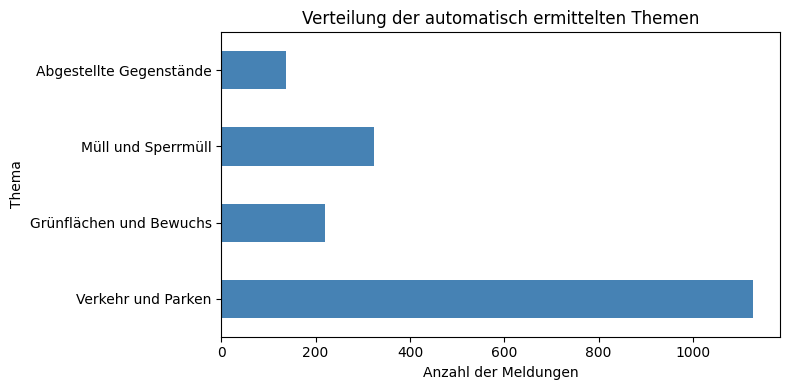

In [23]:
reihenfolge = [
    "Verkehr und Parken",
    "Grünflächen und Bewuchs",
    "Müll und Sperrmüll",
    "Abgestellte Gegenstände"
]

verteilung_plot = (
    df_text["nmf_thema_name"]
    .value_counts()
    .reindex(reihenfolge)
)

verteilung_plot.plot(
    kind="barh",
    color="steelblue",
    figsize=(8, 4)
)

plt.title("Verteilung der automatisch ermittelten Themen")
plt.xlabel("Anzahl der Meldungen")
plt.ylabel("Thema")
plt.tight_layout()
plt.show()

## 10. Beispielmeldungen der Themen

Zur Kontrolle wird für jedes NMF-Thema die Meldung mit der stärksten Zuordnung angezeigt. Dadurch kann geprüft werden, ob die vergebenen Themenbezeichnungen zu den tatsächlichen Beschreibungstexten passen.

In [24]:
for thema_nummer in range(4):
    staerkste_position = np.argmax(
        nmf_ergebnis_4[:, thema_nummer]
    )

    beispieltext = df_text.iloc[
        staerkste_position
    ]["beschreibung"]

    print("\nThema", thema_nummer + 1)
    print(thema_namen[thema_nummer + 1])
    print(beispieltext)


Thema 1
Verkehr und Parken
Man kann als Fußgänger/Radfahrer die Straße nicht einsehen, wenn man sie überqueren möchte. Im etwas zu sehen, muss man schon auf der Straße stehen.

Thema 2
Grünflächen und Bewuchs
Eingeschränkter Gehweg, mit Rosen überwachsen.

Thema 3
Müll und Sperrmüll
Ablagern von Müll am Waldrand.

Thema 4
Abgestellte Gegenstände
Im Schiffbauerring 53 ein befindet sich ein TV-Gerät.


## 11. Fazit

In diesem Projekt wurden die Beschreibungstexte der Klarschiff.HRO-Meldungen untersucht. Nach dem Entfernen fehlender, doppelter und sehr kurzer Texte blieben 1.807 Meldungen für die weitere Analyse übrig.

Für die Textdarstellung wurden CountVectorizer und TF-IDF verwendet. Anschließend wurden mit LDA und NMF zwei Verfahren zur Themenanalyse ausprobiert. Beim ersten LDA-Versuch waren mehrere Themen noch stark vermischt. Auch durch zusätzliche Stoppwörter wurde die Trennung nur teilweise besser.

Die Ergebnisse von NMF waren insgesamt leichter zu verstehen. Bei vier Themen ließen sich die Bereiche Verkehr und Parken, Grünflächen und Bewuchs, Müll und Sperrmüll sowie abgestellte Gegenstände erkennen. Die gefundenen Themen passen in groben Zügen zu den vorhandenen Hauptkategorien des Datensatzes.

Die Zuordnung ist trotzdem nicht immer eindeutig. Einige Meldungen können zu mehreren Themen passen und die Benennung der Themen erfolgte anhand der wichtigsten Wörter. Außerdem haben die gewählten Stoppwörter und die Anzahl der Themen Einfluss auf das Ergebnis. Für eine erste Untersuchung des Datensatzes war NMF aber besser geeignet als LDA.